# Model evaluation and pipelines

A model is only useful if its performance is measured honestly and its preprocessing travels with
it. This notebook builds a full scikit-learn **Pipeline**, tunes it with **GridSearchCV**, and
evaluates with a confusion matrix and ROC curve. It is the capstone that pulls the module together.

## Learning objectives

By the end of this notebook you will be able to:

- build a pipeline that bundles preprocessing and a model;
- estimate performance with stratified K-fold cross-validation;
- tune hyperparameters with `GridSearchCV` without touching the test set;
- read a confusion matrix and choose a threshold for the business cost;
- interpret an ROC curve and AUC.

## Concept

A **pipeline** chains steps so that fitting the pipeline fits every step in order and predicting
applies them in order. This prevents a common bug: fitting a scaler or encoder on the whole dataset
before splitting leaks information from the test set. With a pipeline, cross-validation refits the
preprocessing inside each fold.

**GridSearchCV** exhausts every combination in a parameter grid, cross-validates each, and refits
the best on the full training set. The parameters of nested steps are addressed with double
underscores, for example `model__model__C`.

A **confusion matrix** counts true positives, false positives, false negatives, and true negatives.
Accuracy summarises it, but the matrix shows *which* mistakes the model makes — essential when the
two errors have different costs. The **ROC curve** plots the true-positive rate against the
false-positive rate across every threshold, and **AUC** summarises it as the probability that a
random positive is ranked above a random negative. AUC is useful because it is threshold-free, but
it hides calibration and class balance.

## Worked example

### Prepare the Adult data

In [1]:
import sys
from pathlib import Path

import pandas as pd

sys.path.insert(0, str(Path.cwd().parent))
import ml
from ds_practice import load_uci_adult, set_seed, classification_metrics
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder

set_seed(42)
adult = load_uci_adult().sample(6000, random_state=42).reset_index(drop=True)
adult = adult.assign(target=(adult["income"] == ">50K").astype(int))
X = adult.drop(columns=["income", "target"])
y = adult["target"]
numeric = X.select_dtypes("number").columns.tolist()
categorical = X.select_dtypes("object").columns.tolist()

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
preprocess = ColumnTransformer([
    ("num", "passthrough", numeric),
    ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), categorical),
])
pipeline = Pipeline([("prep", preprocess), ("model", ml.make_classifier("logistic"))])
print("pipeline steps:", [name for name, _ in pipeline.steps])

pipeline steps: ['prep', 'model']


### Cross-validation

Stratified folds keep the class ratio constant, which matters for a skewed target.

In [2]:
from sklearn.model_selection import cross_val_score

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scores = cross_val_score(pipeline, X_train, y_train, cv=cv, scoring="f1")
print("CV F1 per fold:", scores.round(3))
print("mean:", round(scores.mean(), 3), "| std:", round(scores.std(), 3))

CV F1 per fold: [0.665 0.679 0.668 0.635 0.639]
mean: 0.657 | std: 0.017


### Tuning with GridSearchCV

We tune the regularisation strength `C` of the logistic regression. The search is on the training
set only; the test set stays sealed.

In [3]:
from sklearn.model_selection import GridSearchCV

param_grid = {"model__model__C": [0.01, 0.1, 1.0, 10.0]}
search = GridSearchCV(pipeline, param_grid, cv=cv, scoring="f1", n_jobs=1)
search.fit(X_train, y_train)
print("best C:", search.best_params_)
print("best CV F1:", round(search.best_score_, 3))

best C: {'model__model__C': 1.0}
best CV F1: 0.657


### Final evaluation

The tuned model is judged once on the test set, with the full metric set and a confusion matrix.

In [4]:
from sklearn.metrics import confusion_matrix

best = search.best_estimator_
pred = best.predict(X_test)
print("test metrics:", {k: round(v, 3) for k, v in classification_metrics(y_test, pred).items()})
display(pd.DataFrame(
    confusion_matrix(y_test, pred),
    index=["actual <=50K", "actual >50K"],
    columns=["pred <=50K", "pred >50K"],
))

test metrics: {'accuracy': 0.859, 'precision': 0.853, 'recall': 0.859, 'f1': 0.853}


,pred <=50K,pred >50K
actual <=50K,856,53
actual >50K,116,175


### ROC and AUC

The ROC curve shows the trade-off at every threshold; AUC summarises it in one number. The dashed
line is a random classifier.

AUC: 0.9


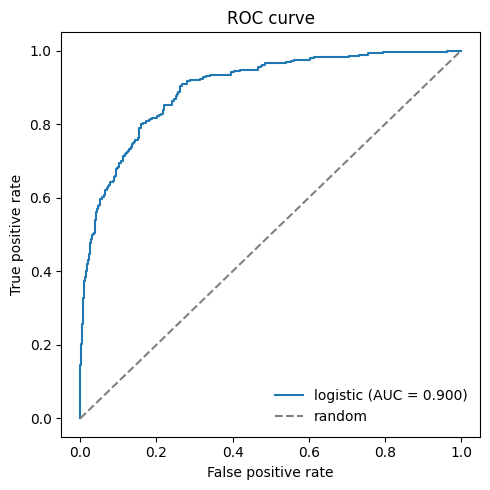

In [5]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score, roc_curve

prob = best.predict_proba(X_test)[:, 1]
fpr, tpr, thresholds = roc_curve(y_test, prob)
auc = roc_auc_score(y_test, prob)
print("AUC:", round(auc, 3))

fig, ax = plt.subplots(figsize=(5, 5))
ax.plot(fpr, tpr, label=f"logistic (AUC = {auc:.3f})")
ax.plot([0, 1], [0, 1], linestyle="--", color="grey", label="random")
ax.set_title("ROC curve")
ax.set_xlabel("False positive rate")
ax.set_ylabel("True positive rate")
ax.legend(frameon=False)
fig.tight_layout()
plt.show()

### Choosing a threshold

AUC is threshold-free, but a deployed model needs one. Raising the threshold increases precision and
lowers recall; the right point depends on which error costs more.

In [6]:
rows = []
for threshold in (0.3, 0.5, 0.7):
    pred_t = (prob >= threshold).astype(int)
    metrics = classification_metrics(y_test, pred_t)
    rows.append({"threshold": threshold, **{k: round(v, 3) for k, v in metrics.items()}})
display(pd.DataFrame(rows))

,threshold,accuracy,precision,recall,f1
0,0.3,0.826,0.843,0.826,0.831
1,0.5,0.859,0.853,0.859,0.853
2,0.7,0.848,0.849,0.848,0.830


## Exercises

1. **Switch the model.** Replace logistic regression with a random forest inside the pipeline and
   tune `model__model__n_estimators` over 100 and 300. Compare the best CV F1.
2. **Threshold policy.** Suppose a false negative costs five times a false positive. Using the
   threshold table, choose a threshold and justify it numerically.
3. **Leakage check.** Explain in three sentences why scaling the whole dataset before
   `train_test_split` would leak information, and how the pipeline prevents it.

## Limitations

`GridSearchCV` over a small grid can still overfit the validation folds if run often, so the final
test score is the honest estimate. AUC assumes the model's probabilities are ranked correctly and
ignores calibration, so a high AUC does not mean the probabilities are accurate. The pipeline
here handles tabular preprocessing only; text, images, and time series need different steps.
Finally, evaluation on a 6,000-row sample is noisy, and a production study would use the full data
and confidence intervals.